In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from mlxtend.plotting import plot_decision_regions

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("placement.csv")
df.head()

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


In [3]:
print(df.shape)
print(df.columns)
df.info()

(100, 3)
Index(['cgpa', 'resume_score', 'placed'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cgpa          100 non-null    float64
 1   resume_score  100 non-null    float64
 2   placed        100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [4]:
df.describe()

,cgpa,resume_score,placed
count,100.0000,100.000000,100.000000
mean,6.9422,6.930500,0.500000
std,1.1192,0.979608,0.502519
min,5.2700,4.950000,0.000000
25%,5.9800,6.190000,0.000000
50%,6.6200,7.055000,0.500000
75%,8.0450,7.640000,1.000000
max,9.4000,9.060000,1.000000


In [5]:
df.isnull().sum()

cgpa            0
resume_score    0
placed          0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["placed"].value_counts()

placed
1    50
0    50
Name: count, dtype: int64

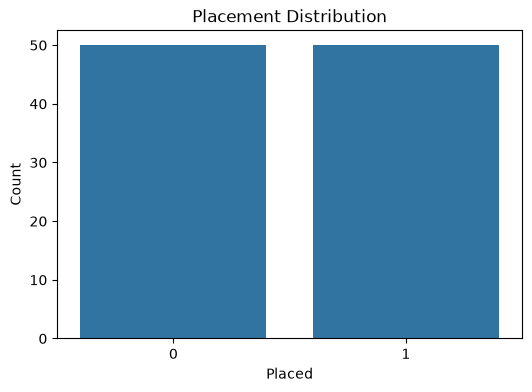

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="placed")
plt.title("Placement Distribution")
plt.xlabel("Placed")
plt.ylabel("Count")
plt.show()

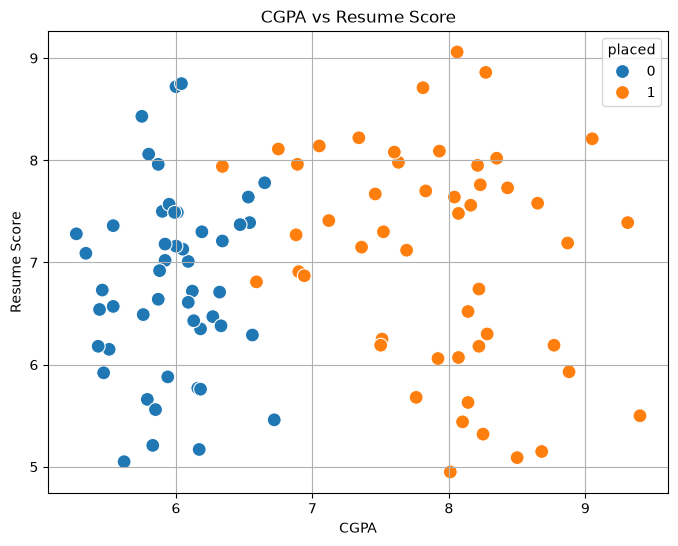

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="cgpa",
    y="resume_score",
    hue="placed",
    s=100
)
plt.title("CGPA vs Resume Score")
plt.xlabel("CGPA")
plt.ylabel("Resume Score")
plt.grid(True)
plt.show()

In [10]:
X = df[["cgpa", "resume_score"]]
y = df["placed"]

In [11]:
print(X.shape)
print(y.shape)

(100, 2)
(100,)


In [12]:
X.head()

,cgpa,resume_score
0,8.14,6.52
1,6.17,5.17
2,8.27,8.86
3,6.88,7.27
4,7.52,7.30


In [13]:
y.head()

0    1
1    0
2    1
3    1
4    1
Name: placed, dtype: int64

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [15]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80, 2)
(20, 2)
(80,)
(20,)


In [16]:
p = Perceptron()
p

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


In [17]:
p.fit(X_train, y_train)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


In [18]:
p.coef_

array([[ 44.42, -41.1 ]])

In [19]:
p.intercept_

array([-47.])

In [20]:
y_train_pred = p.predict(X_train)
y_test_pred = p.predict(X_test)

In [21]:
print(y_train_pred)
print(y_test_pred)

[0 1 0 0 0 1 1 0 1 0 0 0 1 0 1 1 0 0 1 0 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0
 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 1 0 1 0 1 0 0 0 0 0 1 0 0 1
 0 0 0 1 0 0]
[0 0 0 1 0 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0]


In [22]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.7375
Testing Accuracy: 0.75


In [23]:
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")

Training Accuracy: 73.75%
Testing Accuracy: 75.00%


In [24]:
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

[[10  0]
 [ 5  5]]


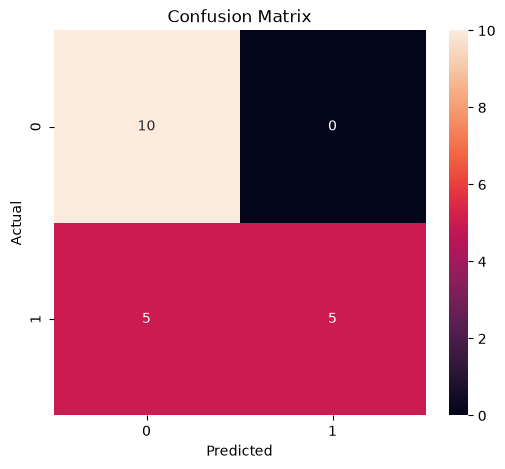

In [25]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80        10
           1       1.00      0.50      0.67        10

    accuracy                           0.75        20
   macro avg       0.83      0.75      0.73        20
weighted avg       0.83      0.75      0.73        20



In [27]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
})

results

,Actual,Predicted
0,1,0
1,0,0
2,1,0
3,1,1
4,0,0
5,1,1
6,0,0
7,1,0
8,0,0
9,1,1


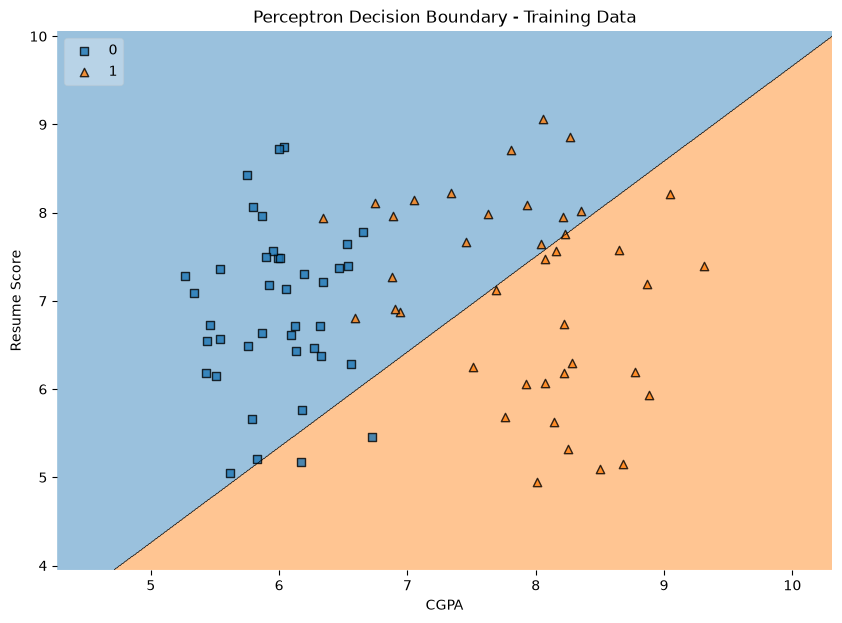

In [28]:
plt.figure(figsize=(10, 7))

plot_decision_regions(
    X_train.values,
    y_train.values,
    clf=p,
    legend=2
)

plt.xlabel("CGPA")
plt.ylabel("Resume Score")
plt.title("Perceptron Decision Boundary - Training Data")
plt.show()

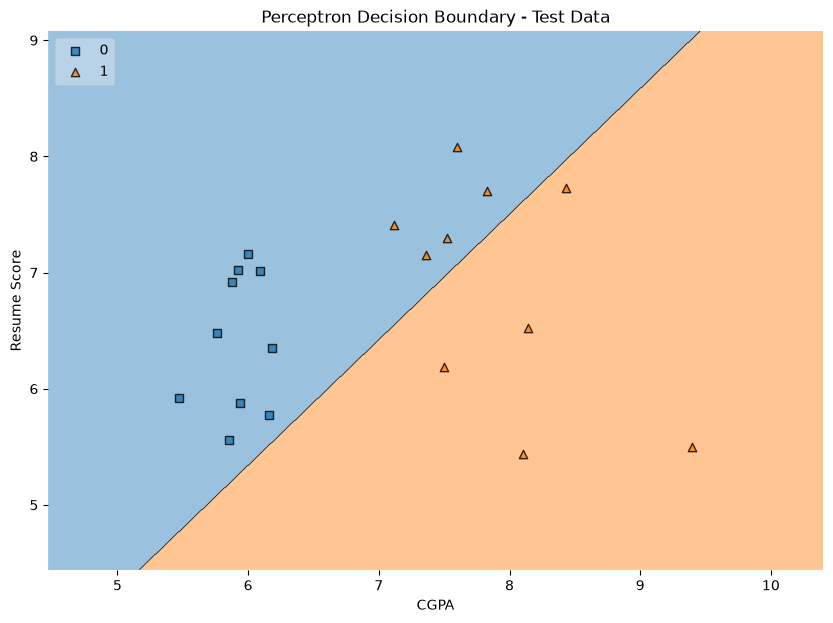

In [29]:
plt.figure(figsize=(10, 7))

plot_decision_regions(
    X_test.values,
    y_test.values,
    clf=p,
    legend=2
)

plt.xlabel("CGPA")
plt.ylabel("Resume Score")
plt.title("Perceptron Decision Boundary - Test Data")
plt.show()

In [30]:
w1 = p.coef_[0][0]
w2 = p.coef_[0][1]
b = p.intercept_[0]

print(w1)
print(w2)
print(b)

44.420000000000165
-41.09999999999995
-47.0


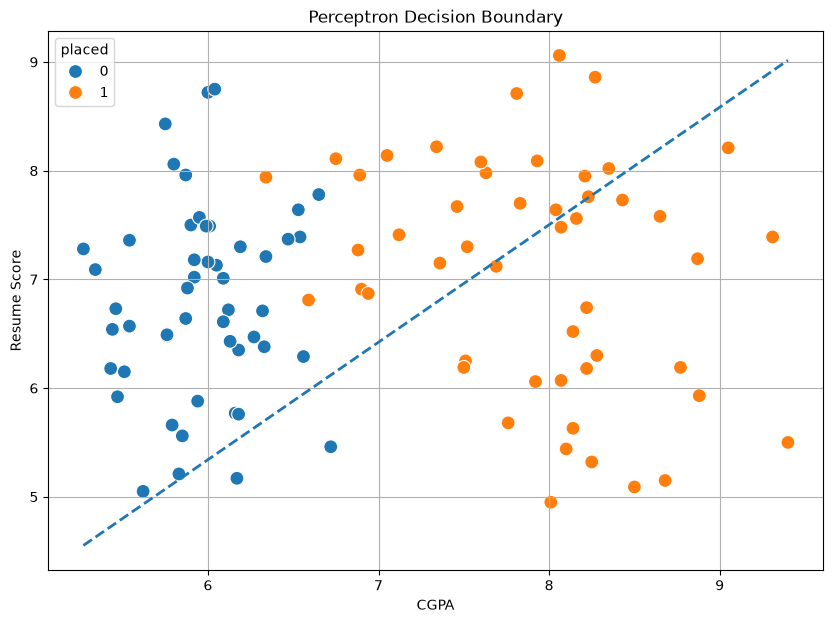

In [31]:
x_values = np.linspace(
    df["cgpa"].min(),
    df["cgpa"].max(),
    100
)

y_values = -(w1 * x_values + b) / w2

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="cgpa",
    y="resume_score",
    hue="placed",
    s=100
)

plt.plot(
    x_values,
    y_values,
    linestyle="--",
    linewidth=2
)

plt.xlabel("CGPA")
plt.ylabel("Resume Score")
plt.title("Perceptron Decision Boundary")
plt.grid(True)
plt.show()

In [32]:
new_student = np.array([[8.5, 8.0]])
prediction = p.predict(new_student)

print(prediction)

[1]


In [33]:
if prediction[0] == 1:
    print("Placed")
else:
    print("Not Placed")

Placed


In [34]:
new_students = np.array([
    [9.0, 9.0],
    [8.5, 8.0],
    [7.0, 6.5],
    [6.0, 5.0],
    [8.0, 7.5]
])

predictions = p.predict(new_students)

prediction_df = pd.DataFrame({
    "CGPA": new_students[:, 0],
    "Resume Score": new_students[:, 1],
    "Prediction": predictions
})

prediction_df

,CGPA,Resume Score,Prediction
0,9.0,9.0,0
1,8.5,8.0,1
2,7.0,6.5,0
3,6.0,5.0,1
4,8.0,7.5,1


In [35]:
class SimplePerceptron:

    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.errors = []

    def activation(self, z):
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        self.errors = []

        for epoch in range(self.epochs):
            error_count = 0

            for xi, target in zip(X, y):
                linear_output = np.dot(xi, self.weights) + self.bias
                prediction = self.activation(linear_output)
                update = self.learning_rate * (target - prediction)

                self.weights += update * xi
                self.bias += update

                if update != 0:
                    error_count += 1

            self.errors.append(error_count)

        return self

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation(linear_output)

In [36]:
X_np = X.values
y_np = y.values

custom_model = SimplePerceptron(
    learning_rate=0.01,
    epochs=100
)

custom_model.fit(X_np, y_np)

In [37]:
print(custom_model.weights)
print(custom_model.bias)

[ 0.5625 -0.2585]
-2.579999999999989


In [38]:
custom_predictions = custom_model.predict(X_np)
print(custom_predictions)

[1 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 1
 1 0 1 1 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 1 0 1 0 1 0]


In [39]:
custom_accuracy = accuracy_score(
    y_np,
    custom_predictions
)

print(custom_accuracy)

0.77


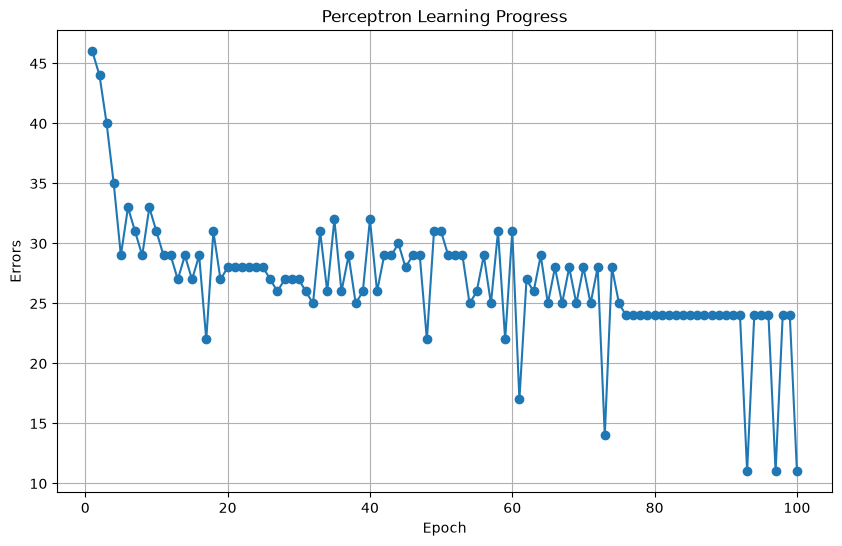

In [40]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(custom_model.errors) + 1),
    custom_model.errors,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Errors")
plt.title("Perceptron Learning Progress")
plt.grid(True)
plt.show()

In [41]:
learning_rates = [0.001, 0.01, 0.1, 1.0]

for lr in learning_rates:
    model = Perceptron(
        eta0=lr,
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    print(
        f"Learning Rate = {lr} -> Accuracy = {accuracy:.4f}"
    )

Learning Rate = 0.001 -> Accuracy = 0.5000
Learning Rate = 0.01 -> Accuracy = 0.5000
Learning Rate = 0.1 -> Accuracy = 0.5000
Learning Rate = 1.0 -> Accuracy = 0.5000


In [42]:
iterations = [10, 50, 100, 500, 1000]

for max_iter in iterations:
    model = Perceptron(
        max_iter=max_iter,
        eta0=0.01,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    print(
        f"Iterations = {max_iter} -> Accuracy = {accuracy:.4f}"
    )

Iterations = 10 -> Accuracy = 0.8000
Iterations = 50 -> Accuracy = 0.5000
Iterations = 100 -> Accuracy = 0.5000
Iterations = 500 -> Accuracy = 0.5000
Iterations = 1000 -> Accuracy = 0.5000


In [43]:
from sklearn.linear_model import LogisticRegression

In [44]:
logistic_model = LogisticRegression()

logistic_model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [45]:
logistic_predictions = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")

Logistic Regression Accuracy: 1.0000


In [46]:
comparison = pd.DataFrame({
    "Model": [
        "Perceptron",
        "Logistic Regression"
    ],
    "Accuracy": [
        test_accuracy,
        logistic_accuracy
    ]
})

comparison

,Model,Accuracy
0,Perceptron,0.75
1,Logistic Regression,1.00
